In [19]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_FILE = Path("nfhs_full5-30.csv")
GEO_FILE = Path("data/india_states.geojson")
META_FILE = Path("data/meta.json")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Publication defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

df_nfhs = pd.read_csv(DATA_FILE)
with open(META_FILE) as f:
    meta = json.load(f)

ROUND_YEARS = meta["round_years"]
WAVE_MAP = {"NFHS-3": 3, "NFHS-4": 4, "NFHS-5": 5, "NFHS-6": 6}
YEAR_MID = {"NFHS-3": 2005.5, "NFHS-4": 2015.5, "NFHS-5": 2020.0, "NFHS-6": 2023.5}

df_nfhs.head()

,state,round,year,area,section,indicator,harmonized_indicator,value,data_flag,source
0,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 5 years (%),NaN,6.6,NaN,NFHS-6 PDF
1,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 5 years (%),NaN,8.6,NaN,NFHS-6 PDF
2,India,NFHS-6,2023-24,Total,Population and Household Profile,Population below age 5 years (%),NaN,8.0,NaN,NFHS-6 PDF
3,India,NFHS-6,2023-24,Urban,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),22.0,NaN,NFHS-6 PDF
4,India,NFHS-6,2023-24,Rural,Population and Household Profile,Population below age 15 years (%),Population below age 15 years (%),27.0,NaN,NFHS-6 PDF


In [20]:
# Keywords
FERTILITY_KW   = ["fertility rate", "tfr", "total fertility",
                        "birth rate", "children born", "births per"]
PHONE_KW       = ["mobile phone", "mobile telephone", "cell phone",
                        "smartphone", "phone ownership", "use mobile"]
INTERNET_KW    = ["internet", "online"]
EDUCATION_KW   = ["literate", "literacy", "education", "schooling",
                        "no education", "secondary", "years of school"]
WEALTH_KW      = ["wealth", "poorest", "richest", "quintile",
                        "household assets", "below poverty"]
URBAN_KW       = ["urban", "rural"]
CONTRACEPTION_KW     = ["contracepti", "family planning", "modern method",
                        "unmet need", "steriliz"]
EMPOWERMENT_KW       = ["decision", "autonomy", "empowerment",
                        "own money", "bank account", "financial"]

# Harmonised indicator crosswalk (Pakhare & Joshi)
HARMONISED = {
    "tfr": "Total fertility rate (children per woman)",
    "mobile": "Women with own mobile phone (%)",
    "internet": "Women who ever used the internet (%)",
    "literacy": "Women (15-49) who are literate (%)",
    "schooling": "Women (15-49) with 10+ years schooling (%)",
    "fp_modern": "FP: Any modern method (%)",
    "unmet_fp": "Total unmet need for FP (%)",
    "empowerment": "Married women participate in HH decisions (%)",
    "electricity": "Households with electricity (%)",
    "bank": "Women with own bank/savings account (%)",
}

MAIN_ROUNDS = ["NFHS-4", "NFHS-5", "NFHS-6"]
INTERNET_ROUNDS = ["NFHS-5", "NFHS-6"]
REG_CONTROLS = ["schooling", "fp_modern", "electricity"]  # literacy absent in NFHS-6

EXCLUDE_STATES = {"India"}
# Legacy UTs split in NFHS-3/4; merged from NFHS-5 onward
LEGACY_UTS = {"Dadra and Nagar Haveli", "Daman and Diu"}

In [21]:


def build_panel(df, rounds, indicators=None, area="Total", require_vars=None):
    """Wide state × round panel from harmonised indicators."""
    indicators = indicators or HARMONISED
    inv = {v: k for k, v in indicators.items()}
    require_vars = require_vars or ["tfr", "mobile"]

    sub = df[
        (df["area"] == area)
        & (~df["state"].isin(EXCLUDE_STATES))
        & (df["round"].isin(rounds))
        & (df["harmonized_indicator"].isin(indicators.values()))
    ].copy()
    sub = sub[~sub["data_flag"].astype(str).str.contains("Parenthesised", na=False)]

    wide = (
        sub.pivot_table(
            index=["state", "round"],
            columns="harmonized_indicator",
            values="value",
            aggfunc="first",
        )
        .rename(columns=inv)
        .reset_index()
    )
    wide["wave"] = wide["round"].map(WAVE_MAP)
    wide["year_mid"] = wide["round"].map(YEAR_MID)
    wide["year_label"] = wide["round"].map(ROUND_YEARS)

    req_cols = require_vars
    complete = wide.dropna(subset=req_cols)
    return wide, complete


panel_all, panel_main = build_panel(
    df_nfhs, MAIN_ROUNDS, require_vars=["tfr", "mobile"]
)
panel_reg = panel_main.dropna(subset=["tfr", "mobile"] + REG_CONTROLS)

panel_main.to_csv(OUTPUT_DIR / "panel_state_total.csv", index=False)
print(f"Main panel: {len(panel_main)} obs, {panel_main['state'].nunique()} states")
print(f"Regression sample: {len(panel_reg)} obs, {panel_reg['state'].nunique()} states")
panel_main.head()

Main panel: 107 obs, 38 states
Regression sample: 107 obs, 38 states


harmonized_indicator,state,round,fp_modern,electricity,empowerment,tfr,unmet_fp,literacy,schooling,internet,bank,mobile,wave,year_mid,year_label
0,Andaman and Nicobar Islands,NFHS-4,48.30,97.00,92.60,1.50,15.50,84.10,49.10,NaN,81.80,66.90,4,2015.5,2015-16
1,Andaman and Nicobar Islands,NFHS-5,57.73,97.58,94.48,1.28,13.51,85.97,52.47,34.79,89.21,80.83,5,2020.0,2019-21
2,Andaman and Nicobar Islands,NFHS-6,66.30,97.50,94.80,0.90,4.60,NaN,65.00,72.00,93.30,86.70,6,2023.5,2023-24
3,Andhra Pradesh,NFHS-4,69.40,98.80,79.90,1.80,4.70,62.90,34.30,NaN,66.30,36.20,4,2015.5,2015-16
4,Andhra Pradesh,NFHS-5,70.84,99.45,84.05,1.68,4.68,68.64,39.63,20.97,81.78,48.94,5,2020.0,2019-21


In [22]:


def build_panel(df, rounds, indicators=None, area="Total", require_vars=None):
    """Wide state × round panel from harmonised indicators."""
    indicators = indicators or HARMONISED
    inv = {v: k for k, v in indicators.items()}
    require_vars = require_vars if require_vars is not None else ["tfr", "mobile"]

    sub = df[
        (df["area"] == area)
        & (~df["state"].isin(EXCLUDE_STATES))
        & (df["round"].isin(rounds))
        & (df["harmonized_indicator"].isin(indicators.values()))
    ].copy()
    sub = sub[~sub["data_flag"].astype(str).str.contains("Parenthesised", na=False)]

    wide = (
        sub.pivot_table(
            index=["state", "round"],
            columns="harmonized_indicator",
            values="value",
            aggfunc="first",
        )
        .rename(columns=inv)
        .reset_index()
    )
    wide["wave"] = wide["round"].map(WAVE_MAP)
    wide["year_mid"] = wide["round"].map(YEAR_MID)
    wide["year_label"] = wide["round"].map(ROUND_YEARS)

    req_cols = require_vars if require_vars else None
    complete = wide.dropna(subset=req_cols) if req_cols else wide.copy()
    return wide, complete


panel_all, panel_main = build_panel(
    df_nfhs, MAIN_ROUNDS, require_vars=["tfr", "mobile"]
)
panel_reg = panel_main.dropna(subset=["tfr", "mobile"] + REG_CONTROLS)

panel_main.to_csv(OUTPUT_DIR / "panel_state_total.csv", index=False)
print(f"Main panel: {len(panel_main)} obs, {panel_main['state'].nunique()} states")
print(f"Regression sample: {len(panel_reg)} obs, {panel_reg['state'].nunique()} states")
panel_main.head()

Main panel: 107 obs, 38 states
Regression sample: 107 obs, 38 states


harmonized_indicator,state,round,fp_modern,electricity,empowerment,tfr,unmet_fp,literacy,schooling,internet,bank,mobile,wave,year_mid,year_label
0,Andaman and Nicobar Islands,NFHS-4,48.30,97.00,92.60,1.50,15.50,84.10,49.10,NaN,81.80,66.90,4,2015.5,2015-16
1,Andaman and Nicobar Islands,NFHS-5,57.73,97.58,94.48,1.28,13.51,85.97,52.47,34.79,89.21,80.83,5,2020.0,2019-21
2,Andaman and Nicobar Islands,NFHS-6,66.30,97.50,94.80,0.90,4.60,NaN,65.00,72.00,93.30,86.70,6,2023.5,2023-24
3,Andhra Pradesh,NFHS-4,69.40,98.80,79.90,1.80,4.70,62.90,34.30,NaN,66.30,36.20,4,2015.5,2015-16
4,Andhra Pradesh,NFHS-5,70.84,99.45,84.05,1.68,4.68,68.64,39.63,20.97,81.78,48.94,5,2020.0,2019-21


In [23]:
# --- Indicator audit: coverage matrix & keyword search ---

def coverage_matrix(df, var, rounds):
    tmp = df[df["round"].isin(rounds)].copy()
    tmp["has_val"] = tmp[var].notna().astype(int)
    return tmp.pivot_table(index="state", columns="round", values="has_val", aggfunc="max", fill_value=0)


print("=" * 60)
print("COVERAGE: TFR and Mobile (Total area, excl. India)")
print("=" * 60)
for label, var in [("TFR", "tfr"), ("Mobile", "mobile")]:
    mat = coverage_matrix(panel_all, var, MAIN_ROUNDS)
    print(f"\n{label} — states with data by round:")
    print(mat.sum(axis=0))
    missing = mat[(mat.sum(axis=1) < len(MAIN_ROUNDS))].index.tolist()
    if missing:
        print(f"  Incomplete states ({len(missing)}): {missing}")

lit_cov = coverage_matrix(panel_all, "literacy", MAIN_ROUNDS)
print(f"\nLiteracy NFHS-6 coverage: {lit_cov['NFHS-6'].sum()} states (0 expected — not harmonised in NFHS-6)")

print("\n" + "=" * 60)
print("ATTRITION")
print("=" * 60)
for desc, n in [
    ("All state-rounds (NFHS-4/5/6)", len(panel_all)),
    ("Non-missing TFR + mobile", len(panel_main)),
    ("+ non-missing controls", len(panel_reg)),
]:
    print(f"  {desc}: {n}")

def kw_match(text, keywords):
    t = str(text).lower()
    return any(k in t for k in keywords)

unmapped_phone = df_nfhs[
    (df_nfhs["area"] == "Total")
    & (~df_nfhs["state"].isin(EXCLUDE_STATES))
    & (df_nfhs["round"].isin(MAIN_ROUNDS))
    & (df_nfhs["harmonized_indicator"].isna() | (df_nfhs["harmonized_indicator"] == ""))
    & df_nfhs["indicator"].apply(lambda x: kw_match(x, PHONE_KW))
]["indicator"].unique()

print("\nUnmapped raw indicators matching PHONE_KW:")
print(unmapped_phone if len(unmapped_phone) else "  None — all phone measures are harmonised.")

COVERAGE: TFR and Mobile (Total area, excl. India)

TFR — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Mobile — states with data by round:
round
NFHS-4    36
NFHS-5    36
NFHS-6    35
dtype: int64
  Incomplete states (5): ['Dadra & Nagar Haveli and Daman & Diu', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Ladakh', 'Manipur']

Literacy NFHS-6 coverage: 0 states (0 expected — not harmonised in NFHS-6)

ATTRITION
  All state-rounds (NFHS-4/5/6): 107
  Non-missing TFR + mobile: 107
  + non-missing controls: 107

Unmapped raw indicators matching PHONE_KW:
  None — all phone measures are harmonised.


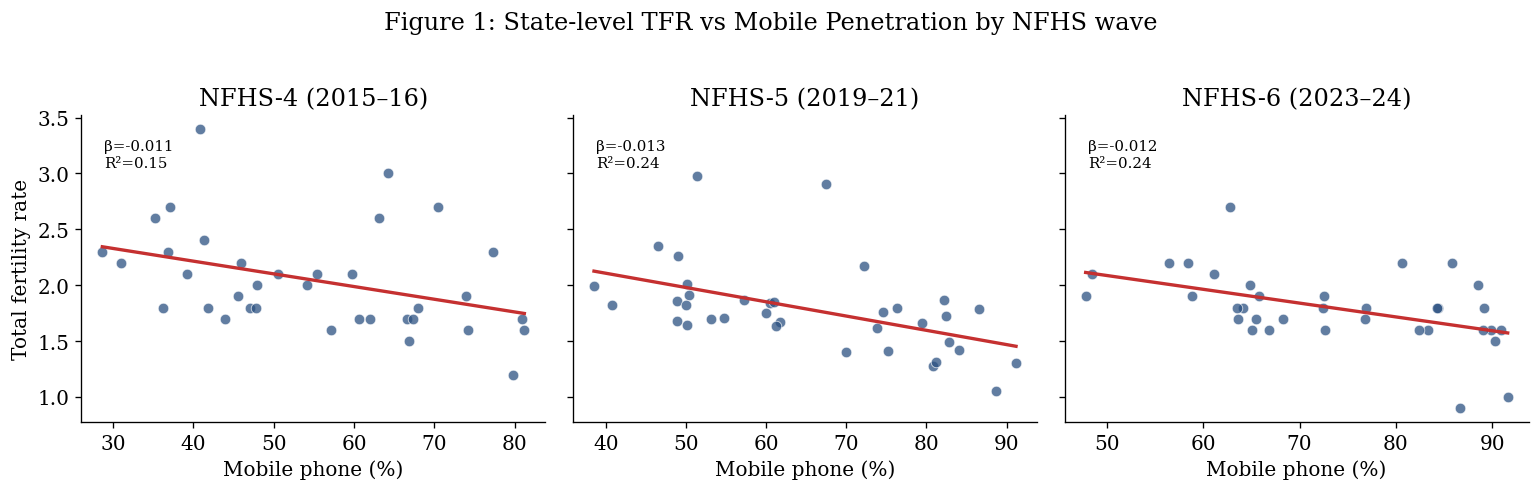

In [24]:
# --- Fig 1: Cross-sectional scatter — TFR vs mobile by wave ---

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
round_labels = {"NFHS-4": "2015–16", "NFHS-5": "2019–21", "NFHS-6": "2023–24"}

for ax, rnd in zip(axes, MAIN_ROUNDS):
    sub = panel_main[panel_main["round"] == rnd]
    ax.scatter(sub["mobile"], sub["tfr"], alpha=0.75, s=40, color="#2c5282", edgecolors="white", lw=0.5)
    if len(sub) >= 5:
        m = smf.ols("tfr ~ mobile", data=sub).fit()
        xline = np.linspace(sub["mobile"].min(), sub["mobile"].max(), 50)
        ax.plot(xline, m.params["Intercept"] + m.params["mobile"] * xline, color="#c53030", lw=2)
        ax.text(0.05, 0.92, f"β={m.params['mobile']:.3f}\nR²={m.rsquared:.2f}",
                transform=ax.transAxes, fontsize=9, va="top")
    ax.set_xlabel("Mobile phone (%)")
    ax.set_title(f"{rnd} ({round_labels[rnd]})")

axes[0].set_ylabel("Total fertility rate")
fig.suptitle("Figure 1: State-level TFR vs Mobile Penetration by NFHS wave", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_scatter_pub.png", bbox_inches="tight")
plt.show()

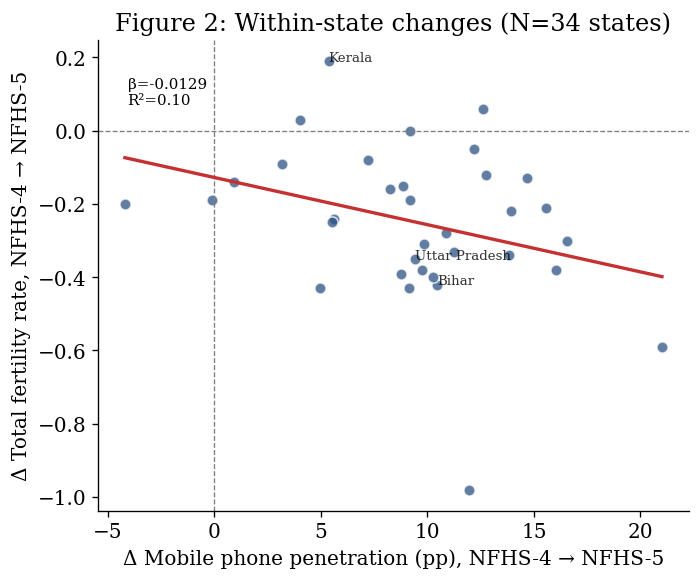

In [25]:
# --- Fig 2: Change-on-change (NFHS-4 → NFHS-5) ---

def wave_slice(df, rnd):
    return df[df["round"] == rnd].set_index("state")[["tfr", "mobile"]]

w4 = wave_slice(panel_main, "NFHS-4")
w5 = wave_slice(panel_main, "NFHS-5")
common = w4.index.intersection(w5.index)
delta = (w5.loc[common] - w4.loc[common]).rename(columns={"tfr": "d_tfr", "mobile": "d_mobile"})

fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.scatter(delta["d_mobile"], delta["d_tfr"], alpha=0.75, s=45, color="#2c5282", edgecolors="white")

if len(delta) >= 5:
    m = smf.ols("d_tfr ~ d_mobile", data=delta.reset_index()).fit()
    xline = np.linspace(delta["d_mobile"].min(), delta["d_mobile"].max(), 50)
    ax.plot(xline, m.params["Intercept"] + m.params["d_mobile"] * xline, color="#c53030", lw=2)
    ax.text(0.05, 0.92, f"β={m.params['d_mobile']:.4f}\nR²={m.rsquared:.2f}",
            transform=ax.transAxes, fontsize=9, va="top")

for st in ["Kerala", "Bihar", "Uttar Pradesh"]:
    if st in delta.index:
        ax.annotate(st, (delta.loc[st, "d_mobile"], delta.loc[st, "d_tfr"]), fontsize=8, alpha=0.8)

ax.set_xlabel("Δ Mobile phone penetration (pp), NFHS-4 → NFHS-5")
ax.set_ylabel("Δ Total fertility rate, NFHS-4 → NFHS-5")
ax.set_title(f"Figure 2: Within-state changes (N={len(delta)} states)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_NFHS4-5change_pub.png", bbox_inches="tight")
plt.show()

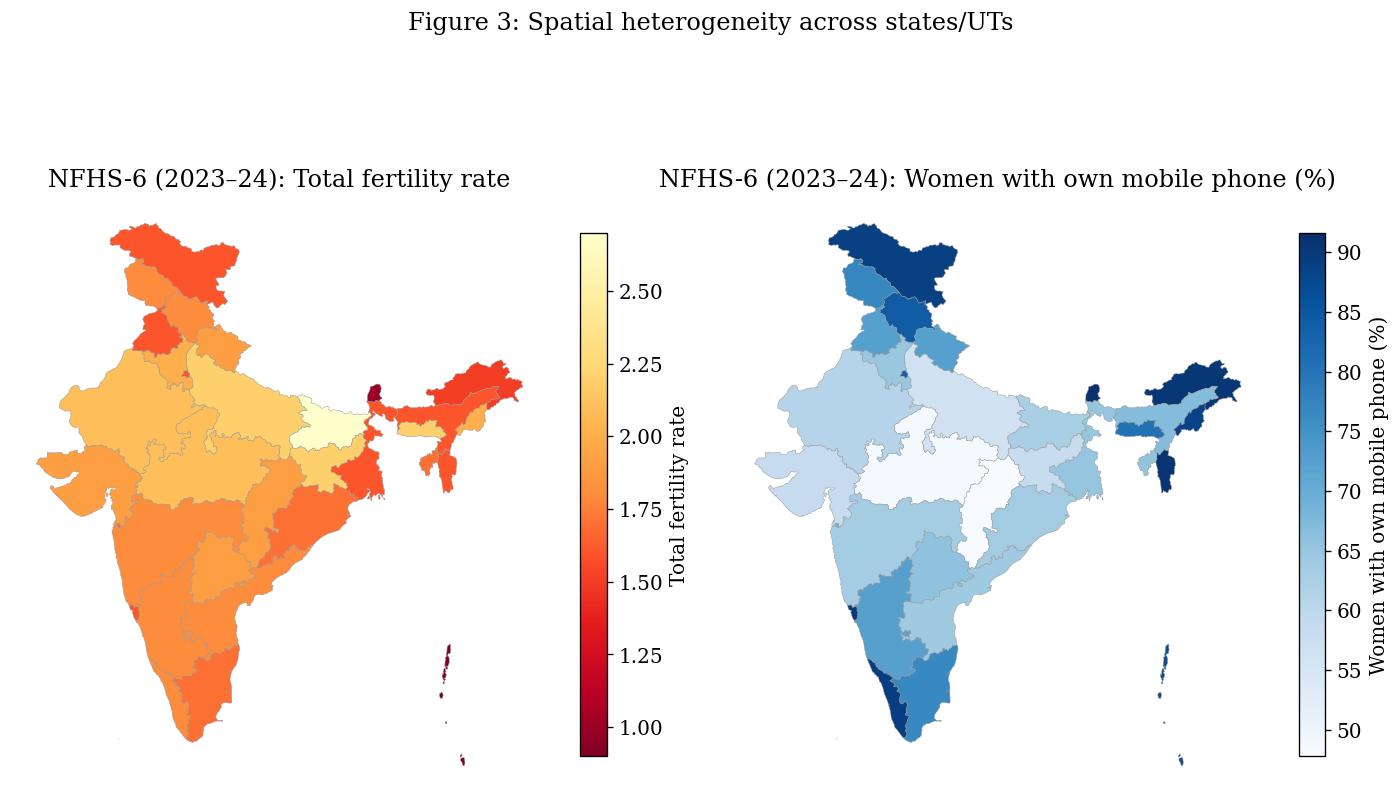

In [ ]:
# --- Fig 3: Choropleth maps — NFHS-6 TFR and mobile ---

STATE_GEO_MAP = {
    "Dadra and Nagar Haveli": "Dadra & Nagar Haveli and Daman & Diu",
    "Daman and Diu": "Dadra & Nagar Haveli and Daman & Diu",
}

nfhs6 = panel_main[panel_main["round"] == "NFHS-6"].copy()
nfhs6["geo_state"] = nfhs6["state"].replace(STATE_GEO_MAP)
gdf = gpd.read_file(GEO_FILE)
map_df = gdf.merge(nfhs6, left_on="state", right_on="geo_state", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for ax, var, title, cmap in [
    (axes[0], "tfr", "Total fertility rate", "YlOrRd_r"),
    (axes[1], "mobile", "Women with own mobile phone (%)", "Blues"),
]:
    map_df.plot(column=var, ax=ax, legend=True, cmap=cmap, edgecolor="0.6", linewidth=0.3,
                legend_kwds={"shrink": 0.6, "label": title})
    ax.set_title(f"NFHS-6 (2023–24): {title}")
    ax.axis("off")

fig.suptitle("Figure 3: Spatial heterogeneity across states/UTs", y=0.98)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig3_choropleth_pub.png", bbox_inches="tight")
plt.show()